In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
# dataset downloaded from: https://www.kaggle.com/datasets/ucimachinelearning/eeg-alzheimers-dataset
csv_path = "eeg_alzheimers_dataset.csv"  # should be local filename - but make sure to upload that here (under files) and rename it first before running this cell.
df = pd.read_csv(csv_path, low_memory=False)

In [2]:
df = df[df["status"].isin([0, 1])].reset_index(drop=True)

In [3]:
# Basic dataset checks
print("CSV shape:", df.shape)  # (rows, cols)
print("Columns:", df.columns.tolist())
print("Missing values total:", df.isna().sum().sum())

CSV shape: (848640, 17)
Columns: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'status']
Missing values total: 0


In [4]:
# Status distribution
label_counts = df["status"].value_counts().sort_index()
print("Rows by status:\n", label_counts)

Rows by status:
 status
0.0    336640
1.0    512000
Name: count, dtype: int64


In [5]:
# Clean status column
#df = df[df["status"].isin([0, 1])].reset_index(drop=True)

status = df["status"].to_numpy()

change_idx = np.where(status[1:] != status[:-1])[0] + 1
boundaries = np.r_[0, change_idx, len(status)]

blocks = []

for i in range(len(boundaries) - 1):
    start = boundaries[i]
    end = boundaries[i + 1]

    blocks.append({
        "block_id": i + 1,
        "status": int(status[start]),
        "start_row": int(start),
        "end_row_excl": int(end),
        "n_samples": int(end - start),
    })

How we figured out # of subjects: <br>
The dataset stores EEG signals as a continuous sequence of time samples rather than separating recordings by subject. To identify individual subjects, we examined the status column, where 0 represents Healthy Controls (HC) and 1 represents Alzheimer’s Disease (AD). Each subject’s recording appears as a continuous block of rows with the same status value. By detecting where the status value changes, we were able to segment the dataset into separate subject recordings. This process produced 18 blocks in total, corresponding to 18 subjects, consisting of 9 AD subjects and 9 HC subjects.

We assume the sampling rate to be 256 Hz (samples/second)

In [6]:
for b in blocks:
    print(b)

{'block_id': 1, 'status': 1, 'start_row': 0, 'end_row_excl': 44800, 'n_samples': 44800}
{'block_id': 2, 'status': 0, 'start_row': 44800, 'end_row_excl': 76800, 'n_samples': 32000}
{'block_id': 3, 'status': 1, 'start_row': 76800, 'end_row_excl': 89600, 'n_samples': 12800}
{'block_id': 4, 'status': 0, 'start_row': 89600, 'end_row_excl': 133120, 'n_samples': 43520}
{'block_id': 5, 'status': 1, 'start_row': 133120, 'end_row_excl': 161280, 'n_samples': 28160}
{'block_id': 6, 'status': 0, 'start_row': 161280, 'end_row_excl': 165120, 'n_samples': 3840}
{'block_id': 7, 'status': 1, 'start_row': 165120, 'end_row_excl': 229120, 'n_samples': 64000}
{'block_id': 8, 'status': 0, 'start_row': 229120, 'end_row_excl': 277760, 'n_samples': 48640}
{'block_id': 9, 'status': 1, 'start_row': 277760, 'end_row_excl': 422400, 'n_samples': 144640}
{'block_id': 10, 'status': 0, 'start_row': 422400, 'end_row_excl': 472320, 'n_samples': 49920}
{'block_id': 11, 'status': 1, 'start_row': 472320, 'end_row_excl': 531

In [7]:
blocks_df = pd.DataFrame(blocks)
blocks_df["label"] = blocks_df["status"].map({0: "HC", 1: "AD"})
print("\nInferred blocks by label:\n", blocks_df["label"].value_counts())


Inferred blocks by label:
 label
AD    9
HC    9
Name: count, dtype: int64


In [8]:
# Sampling rate assumption for Task 1
FS = 256  # <-- Not documented in Kaggle snippet; set to assumed rate for time axis
blocks_df["duration_sec"] = blocks_df["n_samples"] / FS

print("\nPer-block durations (sec) summary:")
print(blocks_df.groupby("label")["duration_sec"].agg(["count", "min", "max", "mean"]))


Per-block durations (sec) summary:
       count   min    max        mean
label                                
AD         9  50.0  565.0  222.222222
HC         9  15.0  200.0  146.111111


In [9]:
# Task 1 matrix shape per “subject/session” (block)
n_channels = 16  # EEG channels (exclude 'status')
print("\nPer-block matrix shape is (Channels x TimeSamples) = (16 x n_samples).")


Per-block matrix shape is (Channels x TimeSamples) = (16 x n_samples).


The raw EEG signals from the P3 channel show differences between healthy controls and Alzheimer’s subjects.

The healthy control signal exhibits more rapid fluctuations, indicating stronger higher-frequency activity.

The Alzheimer’s signal shows slower and broader oscillations, suggesting increased slow-wave activity.

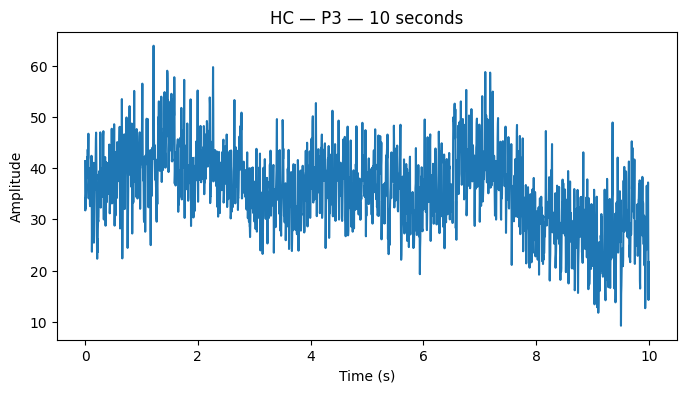

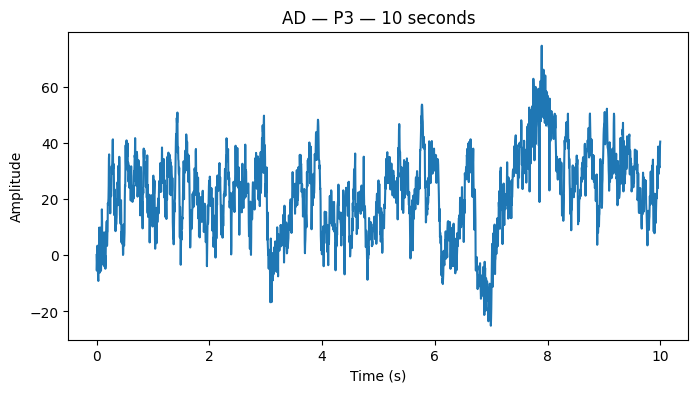

In [10]:
channel = "P3"
n_10sec = 10 * FS

hc_block = blocks_df[blocks_df["label"] == "HC"].iloc[0]
ad_block = blocks_df[blocks_df["label"] == "AD"].iloc[0]

def extract_segment(block):
    start = int(block["start_row"])
    end = start + n_10sec
    segment = df.loc[start:end-1, channel].values
    time = np.arange(len(segment)) / FS
    return time, segment

t_hc, x_hc = extract_segment(hc_block)
t_ad, x_ad = extract_segment(ad_block)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(t_hc, x_hc)
plt.title("HC — P3 — 10 seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(t_ad, x_ad)
plt.title("AD — P3 — 10 seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


In [11]:
print(blocks_df.head())
print(blocks_df["status"].unique())
print(blocks_df["status"].value_counts())

   block_id  status  start_row  end_row_excl  n_samples label  duration_sec
0         1       1          0         44800      44800    AD         175.0
1         2       0      44800         76800      32000    HC         125.0
2         3       1      76800         89600      12800    AD          50.0
3         4       0      89600        133120      43520    HC         170.0
4         5       1     133120        161280      28160    AD         110.0
[1 0]
status
1    9
0    9
Name: count, dtype: int64


**Task 2**



In [12]:
df_raw = pd.read_csv(csv_path, low_memory=False)

# columns
eeg_cols = [c for c in df_raw.columns if c != "status"]

# coerce numeric (footer text -> NaN)
df_raw[eeg_cols] = df_raw[eeg_cols].apply(pd.to_numeric, errors="coerce")
df_raw["status"] = pd.to_numeric(df_raw["status"], errors="coerce")

# keep only valid labels; drop junk/footer/blank rows
df = df_raw[df_raw["status"].isin([0, 1])].copy()
df = df.dropna().reset_index(drop=True)
df["status"] = df["status"].astype("int8")

print("Clean shape:", df.shape)
print(df["status"].value_counts())


Clean shape: (848640, 17)
status
1    512000
0    336640
Name: count, dtype: int64


In [13]:
s = df["status"].to_numpy()
change_idx = np.flatnonzero(np.diff(s) != 0) + 1
bounds = np.r_[0, change_idx, len(s)]

blocks = []
for i in range(len(bounds) - 1):
    a, b = int(bounds[i]), int(bounds[i+1])
    blocks.append({
        "block_id": i + 1,
        "status": int(s[a]),
        "start_row": a,
        "end_row_excl": b,
        "n_samples": b - a
    })

blocks_df = pd.DataFrame(blocks)
blocks_df["label"] = blocks_df["status"].map({0: "HC", 1: "AD"})
print(blocks_df["label"].value_counts())


label
AD    9
HC    9
Name: count, dtype: int64


For each subject block and EEG channel (below), we compute the band power by integrating the PSD over the corresponding frequency range. To make the results comparable across subjects, we also compute relative band power, which represents the proportion of total signal power (between 1–30 Hz) that falls within each band.

The resulting table shows the relative power of each frequency band for every EEG channel and group (AD or HC). These values allow us to compare patterns of brain activity between Alzheimer’s patients and healthy controls and investigate whether AD subjects exhibit the characteristic increase in slow-wave activity (delta/theta) and reduction in faster rhythms (alpha/beta) observed in prior EEG studies.



*   Delta (1–4 Hz) – very slow brain activity
*   Theta (4-8 Hz) - associated with memory processing and drowsiness.
*   Alpha (8-13 Hz - dominant in relaxed, awake states
*   Beta (13-30 Hz) - associated with active thinking and alertness.



In [14]:
from scipy.signal import welch

FS = 256  # ASSUMED if not documented by dataset
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
}
# these bands define the standard EEG frequency bands - standard neuroscience.

def bandpower(f, Pxx, lo, hi):
    m = (f >= lo) & (f < hi)
    if m.sum() < 2:
        return np.nan
    return np.trapz(Pxx[m], f[m])  # integrate PSD over band / computes area under the PSD curve in that band area

rows = []
for _, b in blocks_df.iterrows():
    a, z = int(b.start_row), int(b.end_row_excl)
    label = b.label

    X = df.iloc[a:z][eeg_cols].to_numpy()  # shape: time x channels

    for ci, ch in enumerate(eeg_cols):
        x = X[:, ci]
#Welch 1) splits the signal into chunks, 2) computes FFT on each chunk 3) averages the power spectra
# f = frequencies (x-axis) | Pxx = power at each frequency (y-axis)

        f, Pxx = welch(x, fs=FS, window="hann",
                       nperseg=min(1024, len(x)),
                       noverlap=min(512, max(0, len(x)//2 - 1)),
                       detrend="constant", scaling="density",
                       average="mean")

        total_1_30 = bandpower(f, Pxx, 1, 30)

        out = {"block_id": int(b.block_id), "label": label, "channel": ch}
        for name, (lo, hi) in bands.items():
            p = bandpower(f, Pxx, lo, hi)
            out[f"{name}_abs"] = p
            out[f"{name}_rel"] = p / total_1_30 if total_1_30 else np.nan

        rows.append(out)

band_df = pd.DataFrame(rows)

# Example table format requested (per group mean, per channel)
table = (band_df.groupby(["label","channel"])
         [["delta_rel","theta_rel","alpha_rel","beta_rel"]]
         .mean()
         .reset_index())

print(table.head)


/tmp/ipykernel_15776/2665944240.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[m], f[m])  # integrate PSD over band / computes area under the PSD curve in that band area
/tmp/ipykernel_15776/2665944240.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[m], f[m])  # integrate PSD over band / computes area under the PSD curve in that band area
/tmp/ipykernel_15776/2665944240.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[m], f[m])  # integrate PSD over band / computes area under the PSD curve in that band area
/tmp/ipykernel_15776/2665944240.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integ

<bound method NDFrame.head of    label channel  delta_rel  theta_rel  alpha_rel  beta_rel
0     AD      C3   0.459192   0.211587   0.178210  0.120090
1     AD      C4   0.492915   0.230500   0.152499  0.095492
2     AD      Cz   0.448151   0.184090   0.225919  0.111050
3     AD      F3   0.430499   0.244805   0.159911  0.129786
4     AD      F4   0.453928   0.191363   0.136358  0.187527
5     AD      F7   0.442450   0.233760   0.159724  0.129612
6     AD      F8   0.576327   0.169391   0.109565  0.118563
7     AD     Fp1   0.391054   0.201890   0.139644  0.236134
8     AD     Fp2   0.402252   0.209442   0.152264  0.202947
9     AD      Fz   0.479629   0.187339   0.133117  0.170090
10    AD      P3   0.400469   0.172724   0.107307  0.290419
11    AD      P4   0.447190   0.210370   0.184552  0.125049
12    AD      Pz   0.456936   0.252065   0.137221  0.120556
13    AD      T3   0.590386   0.169543   0.111968  0.100754
14    AD      T4   0.422468   0.196482   0.237264  0.113486
15    AD  

The Welch PSD line and graph plots below shows that Alzheimer’s subjects exhibit stronger power in low-frequency bands (delta and theta), while healthy controls display a stronger alpha peak around 8–12 Hz. This indicates increased slow-wave activity and reduced alpha rhythms in AD subjects, reflecting the characteristic EEG slowing observed in Alzheimer’s disease. This pattern is called EEG slowing: a well-known signature of Alzheimer's disease.

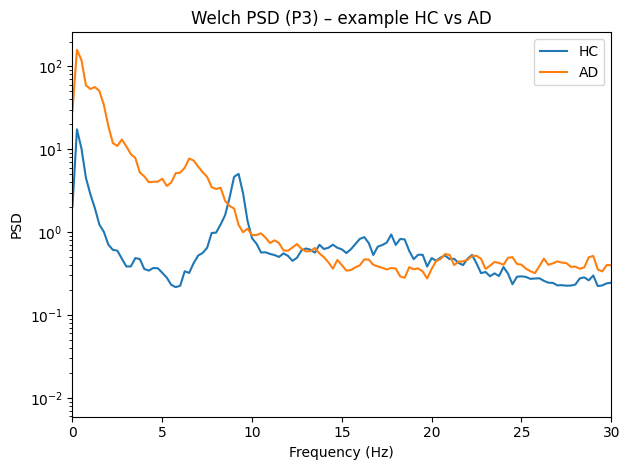

In [15]:
import matplotlib.pyplot as plt

# pick one AD block and one HC block; same channel
ad_block = blocks_df[blocks_df["label"] == "AD"].iloc[0]
hc_block = blocks_df[blocks_df["label"] == "HC"].iloc[0]
ch = "P3"

def get_signal(block):
    a = int(block.start_row); z = int(block.end_row_excl)
    return df.iloc[a:z][ch].to_numpy()

x_ad = get_signal(ad_block)
x_hc = get_signal(hc_block)

f_ad, P_ad = welch(x_ad, fs=FS, nperseg=1024, noverlap=512)
f_hc, P_hc = welch(x_hc, fs=FS, nperseg=1024, noverlap=512)

plt.figure()
plt.semilogy(f_hc, P_hc, label="HC")
plt.semilogy(f_ad, P_ad, label="AD")
plt.xlim(0, 30)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Welch PSD (P3) – example HC vs AD")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
summary = band_df.groupby("label")[["delta_rel","theta_rel","alpha_rel","beta_rel"]].mean()

print(summary.round(3))

       delta_rel  theta_rel  alpha_rel  beta_rel
label                                           
AD         0.454      0.203      0.152     0.159
HC         0.269      0.119      0.280     0.305


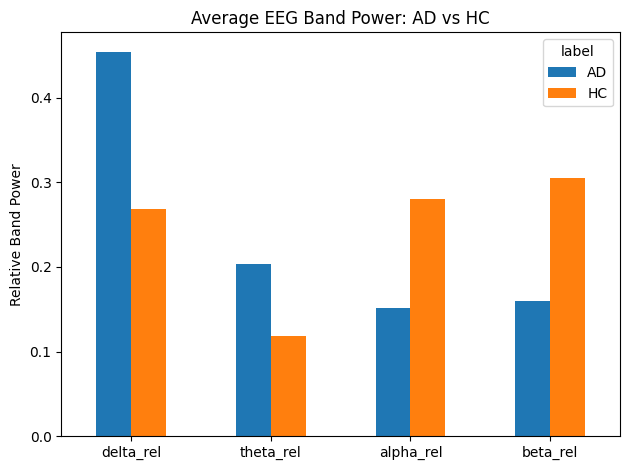

In [17]:
summary.T.plot(kind="bar")

plt.ylabel("Relative Band Power")
plt.title("Average EEG Band Power: AD vs HC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Task 3:**

To prepare the data for statistical comparison, the band power values were averaged across EEG channels for each of these 18 subjects (9 HC / 9 AD). This produced one representative band power value per subject for each frequency band (delta, theta, alpha, beta).

In [18]:
# Computing mean band power per subject (average across channels)
subject_band = (
    band_df
    .groupby(["block_id", "label"])[["delta_rel", "theta_rel", "alpha_rel", "beta_rel"]]
    .mean()
    .reset_index()
)

print(subject_band)

    block_id label  delta_rel  theta_rel  alpha_rel  beta_rel
0          1    AD   0.597881   0.216404   0.065213  0.091734
1          2    HC   0.133237   0.057434   0.654405  0.138324
2          3    AD   0.580193   0.185267   0.124167  0.081392
3          4    HC   0.283037   0.112119   0.332888  0.240829
4          5    AD   0.517599   0.103394   0.139173  0.218958
5          6    HC   0.293338   0.140360   0.203122  0.321521
6          7    AD   0.495743   0.160856   0.135640  0.181769
7          8    HC   0.241035   0.109321   0.191002  0.431256
8          9    AD   0.423821   0.269929   0.150559  0.113849
9         10    HC   0.292470   0.243991   0.185649  0.246514
10        11    AD   0.586078   0.191063   0.064150  0.137745
11        12    HC   0.336974   0.138192   0.253438  0.233782
12        13    AD   0.150810   0.316671   0.345717  0.150592
13        14    HC   0.227459   0.088366   0.380992  0.279602
14        15    AD   0.337932   0.187423   0.216403  0.216467
15      

The boxplot shows that alpha power is lower in the AD group than in the HC group. The median alpha value for AD subjects is around 0.13, while for HC subjects it is around 0.20. This indicates that healthy controls have stronger alpha activity compared to Alzheimer’s patients.

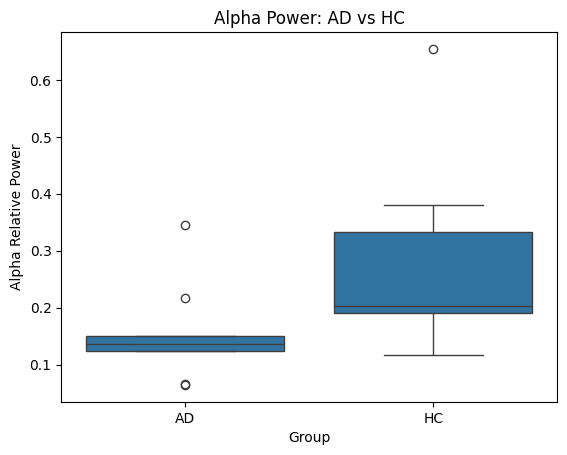

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="label", y="alpha_rel", data=subject_band)
plt.title("Alpha Power: AD vs HC")
plt.xlabel("Group")
plt.ylabel("Alpha Relative Power")
plt.show()

The boxplot shows that theta power is higher in the AD group than in the HC group. The median theta value for AD subjects is about 0.19, while for HC subjects it is around 0.11. This indicates that Alzheimer’s patients exhibit increased slow-wave activity compared to healthy controls.

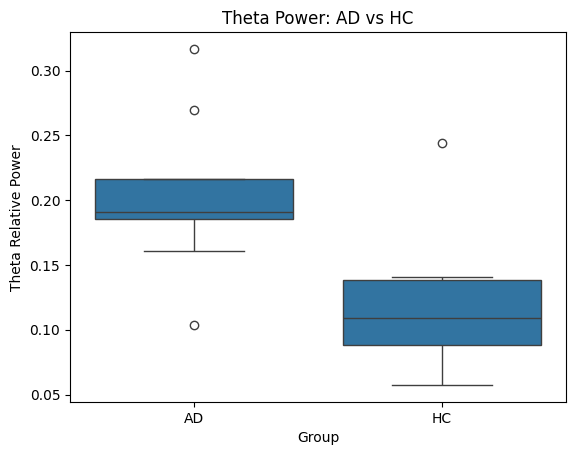

In [20]:
plt.figure()
sns.boxplot(x="label", y="theta_rel", data=subject_band)
plt.title("Theta Power: AD vs HC")
plt.xlabel("Group")
plt.ylabel("Theta Relative Power")
plt.show()

Together, these box plot results show that AD subjects have lower alpha power and higher theta power compared to HC subjects, indicating a shift toward slower brain activity in Alzheimer’s disease.

*   **p < 0.05 → statistically significant difference**
*   **p ≥ 0.05 → not statistically significant**

  Alpha power is lower in Alzheimer’s subjects compared to healthy controls, but the difference is not statistically significant (p ≈ 0.053).

*   The negative t-statistic means alpha power is lower in AD than HC.
*   But the p-value (0.0527) is slightly above 0.05, so the difference is not statistically significant at the 0.05 level.

  Theta power is significantly higher in Alzheimer’s subjects compared to healthy controls (p < 0.01).

*   The positive t-statistic means theta power is higher in AD than HC.
*   The p-value (0.0065) is much smaller than 0.05, so the difference is statistically significant.







In [21]:
from scipy.stats import ttest_ind

# Separate groups
ad = subject_band[subject_band["label"] == "AD"]
hc = subject_band[subject_band["label"] == "HC"]

# Alpha power t-test
t_alpha, p_alpha = ttest_ind(ad["alpha_rel"], hc["alpha_rel"])

# Theta power t-test
t_theta, p_theta = ttest_ind(ad["theta_rel"], hc["theta_rel"])

print("Alpha Power t-test:")
print("t-statistic:", t_alpha)
print("p-value:", p_alpha)

print("\nTheta Power t-test:")
print("t-statistic:", t_theta)
print("p-value:", p_theta)

Alpha Power t-test:
t-statistic: -2.09233151785938
p-value: 0.05270640855332823

Theta Power t-test:
t-statistic: 3.1232195091374484
p-value: 0.00655313473635906


The statistical analysis above shows that theta power is significantly higher in Alzheimer’s patients compared to healthy controls (p < 0.01), while alpha power is lower in Alzheimer’s patients but does not reach statistical significance (p ≈ 0.053). These findings support the known EEG slowing associated with Alzheimer’s disease.

**Building Classification Model**

We are selecting a mix of simple and more complex classification models to evaluate how well EEG frequency features can distinguish between Alzheimer’s Disease (AD) and Healthy Controls (HC). Logistic Regression and SVM were chosen as baseline models because they perform well on small datasets and can capture linear relationships in the data. Random Forest and Gradient Boosting were included as ensemble methods to test whether more complex, non-linear models improve performance. In essence, this comparison helps determine whether the classification problem is simple (linear) or requires more advanced modeling.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [23]:
print("df shape:", df.shape)
print("\nblocks_df head:")
print(blocks_df.head())

print("\nSubject counts:")
print(blocks_df["label"].value_counts())

print("\nEEG columns:")
eeg_cols = [c for c in df.columns if c != "status"]
print(eeg_cols)
print("Number of EEG channels:", len(eeg_cols))

df shape: (848640, 17)

blocks_df head:
   block_id  status  start_row  end_row_excl  n_samples label
0         1       1          0         44800      44800    AD
1         2       0      44800         76800      32000    HC
2         3       1      76800         89600      12800    AD
3         4       0      89600        133120      43520    HC
4         5       1     133120        161280      28160    AD

Subject counts:
label
AD    9
HC    9
Name: count, dtype: int64

EEG columns:
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4']
Number of EEG channels: 16


The Welch method as used in the last step was used to compute the power spectrum, and the energy in each frequency band (delta, theta, alpha, beta) was calculated. These values are now getting normalized to obtain relative band power, which is later used as input features for machine learning.

In [24]:
band_df = pd.DataFrame(rows)

print("band_df shape:", band_df.shape)
print("\nLabel counts in band_df:")
print(band_df["label"].value_counts())
print("\nFirst few rows:")
print(band_df.head())

band_df shape: (288, 11)

Label counts in band_df:
label
AD    144
HC    144
Name: count, dtype: int64

First few rows:
   block_id label channel  delta_abs  delta_rel  theta_abs  theta_rel  \
0         1    AD     Fp1  36.494030   0.572956  15.731602   0.246986   
1         1    AD     Fp2  27.189936   0.543550  12.786948   0.255622   
2         1    AD      F7  34.811631   0.510821  20.030757   0.293929   
3         1    AD      F3  31.035970   0.530498  16.144110   0.275952   
4         1    AD      Fz  50.773429   0.385402  22.899456   0.173821   

   alpha_abs  alpha_rel   beta_abs  beta_rel  
0   4.563756   0.071651   4.925074  0.077324  
1   4.514205   0.090243   3.879063  0.077546  
2   6.343779   0.093088   4.115985  0.060397  
3   5.794927   0.099053   3.292927  0.056286  
4   8.808768   0.066864  46.102015  0.349943  


In [25]:
feature_df = (
    band_df
    .pivot_table(
        index=["block_id", "label"],
        columns="channel",
        values=["delta_rel", "theta_rel", "alpha_rel", "beta_rel"]
    )
)

feature_df.columns = [f"{band}_{channel}" for band, channel in feature_df.columns]
feature_df = feature_df.reset_index()

print("feature_df shape:", feature_df.shape)
print("\nfeature_df labels:")
print(feature_df["label"].value_counts())
print("\nfeature_df preview:")
print(feature_df.head())

feature_df shape: (18, 66)

feature_df labels:
label
AD    9
HC    9
Name: count, dtype: int64

feature_df preview:
   block_id label  alpha_rel_C3  alpha_rel_C4  alpha_rel_Cz  alpha_rel_F3  \
0         1    AD      0.053880      0.041269      0.056417      0.099053   
1         2    HC      0.807865      0.634894      0.868451      0.715436   
2         3    AD      0.127904      0.109537      0.128663      0.180679   
3         4    HC      0.360997      0.462013      0.401860      0.135137   
4         5    AD      0.208082      0.155759      0.221397      0.132323   

   alpha_rel_F4  alpha_rel_F7  alpha_rel_F8  alpha_rel_Fp1  ...  theta_rel_F8  \
0      0.084829      0.093088      0.054656       0.071651  ...      0.160901   
1      0.601761      0.752361      0.622038       0.716056  ...      0.054279   
2      0.139509      0.178168      0.069221       0.104678  ...      0.132216   
3      0.243159      0.274663      0.176494       0.329609  ...      0.100287   
4      0.101625 

In [26]:
X = feature_df.drop(columns=["block_id", "label"])
y = feature_df["label"].map({"HC": 0, "AD": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny counts:")
print(y.value_counts())

X shape: (18, 64)
y shape: (18,)

y counts:
label
1    9
0    9
Name: count, dtype: int64


Because the dataset contains only 18 subjects, we are using Leave-One-Out Cross Validation (LOO) to evaluate model performance. The model is trained on 17 subjects and tested on the remaining one, repeating this process for all subjects. This ensures that every subject is tested while reducing overfitting.

In [27]:
loo = LeaveOneOut()

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

y_pred_logreg = cross_val_predict(logreg_model, X, y, cv=loo)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y, y_pred_logreg))
print("\nClassification Report:\n")
print(classification_report(y, y_pred_logreg, target_names=["HC", "AD"]))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_logreg))

Logistic Regression Results
Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

          HC       0.89      0.89      0.89         9
          AD       0.89      0.89      0.89         9

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18

Confusion Matrix:
 [[8 1]
 [1 8]]


C            Accuracy
-------------------------
0.0001       0.0000
0.001        0.5000
0.01         0.8889
0.1          0.8889
1            0.8889
10           0.8333
100          0.8333
1000         0.8333

Best accuracy       : 0.8888888888888888
Best c : 0.0100


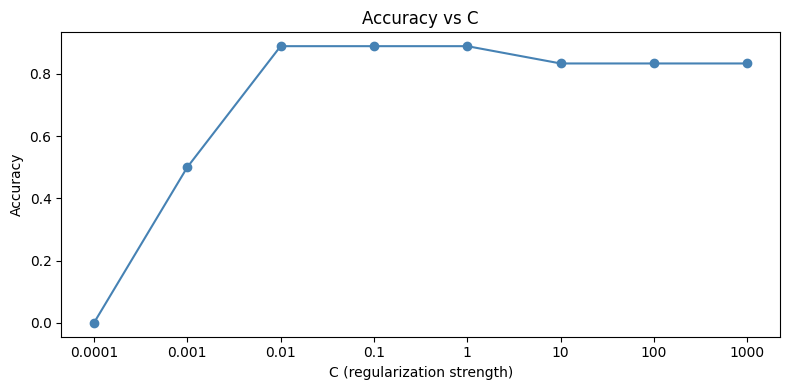

In [28]:
# Tuning hyperparameters for Regularization Strength
regularization_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
accuracies = []

print(f"{'C':<12} {'Accuracy'}")
print("-" * 25)

for C in regularization_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=1000))
    ])

    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)

    print(f"{C:<12} {acc:.4f}")

print(f"\nBest accuracy       : {max(accuracies)}")
print(f"Best c : {regularization_values[accuracies.index(max(accuracies))]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(c) for c in regularization_values], accuracies, marker='o', color='steelblue')
plt.xlabel("C (regularization strength)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C")
plt.tight_layout()
plt.show()

The optimal balance is achieved at C = 0.01.

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

y_pred_gb = cross_val_predict(gb_model, X, y, cv=loo)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y, y_pred_gb))
print("\nClassification Report:\n")
print(classification_report(y, y_pred_gb, target_names=["HC", "AD"]))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.6111111111111112

Classification Report:

              precision    recall  f1-score   support

          HC       0.58      0.78      0.67         9
          AD       0.67      0.44      0.53         9

    accuracy                           0.61        18
   macro avg       0.62      0.61      0.60        18
weighted avg       0.62      0.61      0.60        18

Confusion Matrix:
 [[7 2]
 [5 4]]


0.6666666666666666
0.6666666666666666
0.6111111111111112
0.6111111111111112
0.6111111111111112

Best n_estimators : 10
Best accuracy     : 0.6667


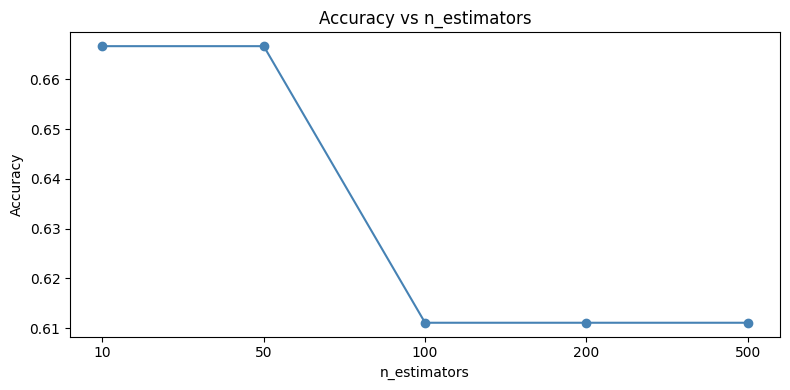

In [30]:
n_estimator_values = [10, 50, 100, 200, 500]
accuracies = []
for n in n_estimator_values:
    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(acc)
best_acc = max(accuracies)
best_n = n_estimator_values[accuracies.index(best_acc)]

print(f"\nBest n_estimators : {best_n}")
print(f"Best accuracy     : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(n) for n in n_estimator_values], accuracies, marker='o', color='steelblue')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Accuracy vs n_estimators")
plt.tight_layout()
plt.show()

Increasing the number of boosting stages (n_estimators) in the Gradient Boosting model did not improve performance. The best accuracy (66.7%) was achieved with 10 estimators (and tied at 50), while using 100, 200, or 500 estimators reduced accuracy to about 61.1%. A simpler Gradient Boosting model performs better than a larger one on this data.

0.0
0.3888888888888889
0.6666666666666666
0.5555555555555556
0.7777777777777778
0.5555555555555556

Best learning_rate : 0.5
Best accuracy      : 0.7778


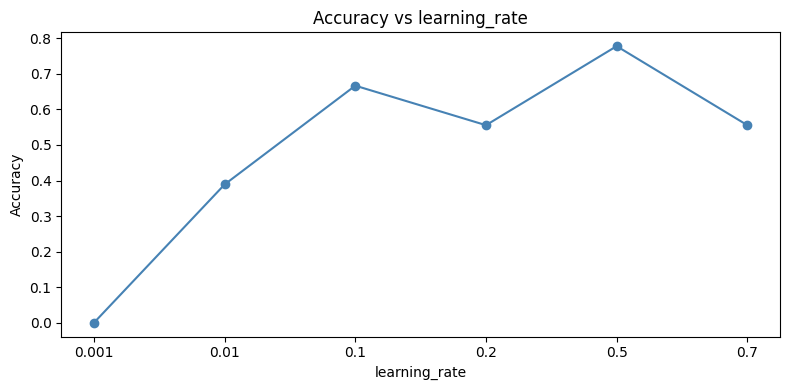

In [31]:
learning_rate_values = [0.001, 0.01, 0.1, 0.2, 0.5, 0.7]
accuracies = []
for lr in learning_rate_values:
    model = GradientBoostingClassifier(
        n_estimators=10,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )

    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(acc)

best_acc = max(accuracies)
best_lr = learning_rate_values[accuracies.index(best_acc)]

print(f"\nBest learning_rate : {best_lr}")
print(f"Best accuracy      : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(lr) for lr in learning_rate_values], accuracies, marker='o', color='steelblue')
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("Accuracy vs learning_rate")
plt.tight_layout()
plt.show()

The best performance was achieved at learning_rate = 0.5 (accuracy = 77.8%). Lower values underfit the data, while higher values reduce performance, showing that a moderate learning rate is optimal.

0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778

Best max_depth : 1
Best accuracy  : 0.7778


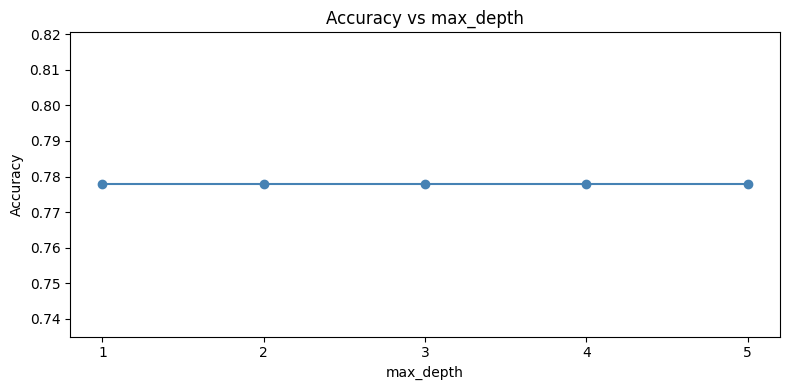

In [32]:
max_depth_values = [1, 2, 3, 4, 5]
accuracies = []

for depth in max_depth_values:
    model = GradientBoostingClassifier(
        n_estimators=10,
        learning_rate=0.5,
        max_depth=depth,
        random_state=42
    )

    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(acc)

best_acc = max(accuracies)
best_depth = max_depth_values[accuracies.index(best_acc)]

print(f"\nBest max_depth : {best_depth}")
print(f"Best accuracy  : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(d) for d in max_depth_values], accuracies, marker='o', color='steelblue')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs max_depth")
plt.tight_layout()
plt.show()


Varying max_depth did not change accuracy (all = 77.8%), indicating that increasing tree complexity does not improve performance. A shallow model (depth = 1) is sufficient.

In [33]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear"))
])

y_pred_svm = cross_val_predict(svm_model, X, y, cv=loo)

print("SVM Results")
print("Accuracy:", accuracy_score(y, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y, y_pred_svm, target_names=["HC", "AD"]))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_svm))

SVM Results
Accuracy: 0.7777777777777778

Classification Report:

              precision    recall  f1-score   support

          HC       0.78      0.78      0.78         9
          AD       0.78      0.78      0.78         9

    accuracy                           0.78        18
   macro avg       0.78      0.78      0.78        18
weighted avg       0.78      0.78      0.78        18

Confusion Matrix:
 [[7 2]
 [2 7]]


0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778

Best C        : 0.0001
Best accuracy : 0.7778


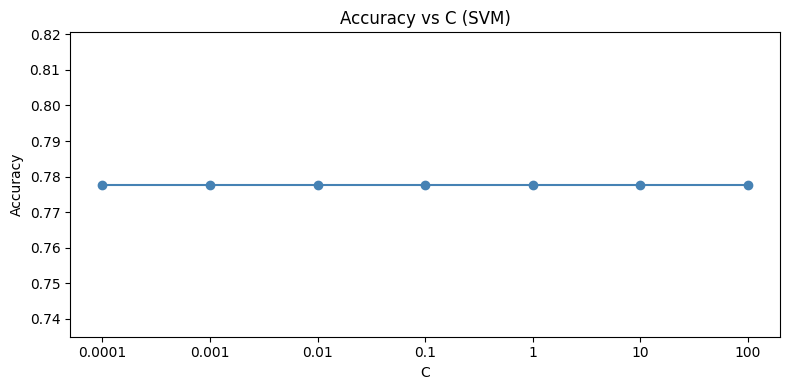

In [34]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
accuracies = []

for c in c_values:
  svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=c))
])

  y_pred = cross_val_predict(model, X, y, cv=loo)
  acc = accuracy_score(y, y_pred)
  accuracies.append(acc)
  print(acc)

best_acc = max(accuracies)
best_C = c_values[accuracies.index(best_acc)]

print(f"\nBest C        : {best_C}")
print(f"Best accuracy : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(c) for c in c_values], accuracies, marker='o', color='steelblue')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C (SVM)")
plt.tight_layout()
plt.show()

All values of C give the same accuracy (77.8%), so changing C has no effect on the model.

Varying the regularization parameter C in the SVM model did not affect performance, as accuracy remained constant at 77.8% for all values. This indicates that the model is not sensitive to regularization on this dataset. A smaller C (0.0001) is preferred since it provides simpler regularization without reducing performance.

0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778

Best kernel        : 0.0001
Best accuracy : 0.7778


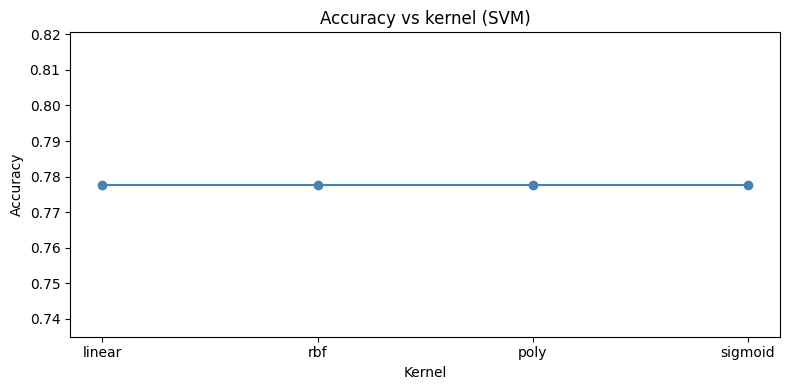

In [35]:
kernel_values = ["linear", "rbf", "poly", "sigmoid"]
accuracies = []

for k in kernel_values:
  svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel=k, C=0.0001))
])

  y_pred = cross_val_predict(model, X, y, cv=loo)
  acc = accuracy_score(y, y_pred)
  accuracies.append(acc)
  print(acc)

best_acc = max(accuracies)
best_C = c_values[accuracies.index(best_acc)]

print(f"\nBest kernel        : {best_C}")
print(f"Best accuracy : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(k) for k in kernel_values], accuracies, marker='o', color='steelblue')
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("Accuracy vs kernel (SVM)")
plt.tight_layout()
plt.show()

All kernels performed identically (77.8%), suggesting that a simple linear model is sufficient for this dataset.
(Data is already linearly separable, and more complex kernels do not provide any additional benefit.)

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

y_pred_rf = cross_val_predict(rf_model, X, y, cv=loo)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y, y_pred_rf, target_names=["HC", "AD"]))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_rf))

Random Forest Results
Accuracy: 0.7777777777777778

Classification Report:

              precision    recall  f1-score   support

          HC       0.73      0.89      0.80         9
          AD       0.86      0.67      0.75         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18

Confusion Matrix:
 [[8 1]
 [3 6]]


0.7222222222222222
0.7777777777777778
0.7777777777777778
0.7777777777777778
0.7777777777777778

Best n_estimators : 50
Best accuracy     : 0.7778


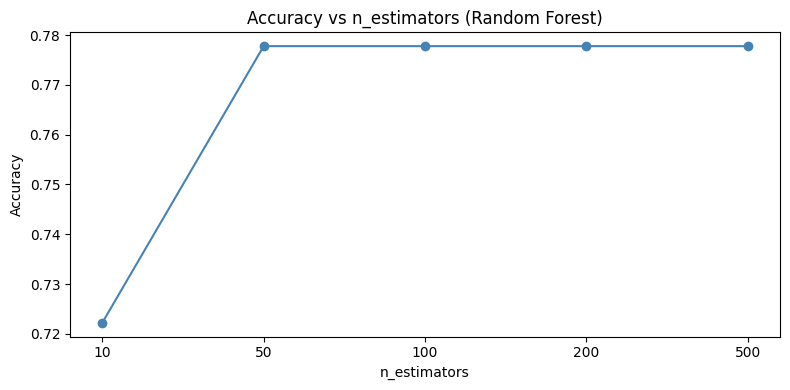

In [37]:
n_estimator_values = [10, 50, 100, 200, 500]
accuracies = []

for n in n_estimator_values:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        random_state=42
    )

    y_pred = cross_val_predict(model, X, y, cv=loo)
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(acc)

best_acc = max(accuracies)
best_n = n_estimator_values[accuracies.index(best_acc)]

print(f"\nBest n_estimators : {best_n}")
print(f"Best accuracy     : {best_acc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot([str(n) for n in n_estimator_values], accuracies, marker='o', color='steelblue')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Accuracy vs n_estimators (Random Forest)")
plt.tight_layout()
plt.show()

Performance improved up to 50 trees, after which accuracy plateaued at 77.8%, showing no benefit from adding more trees.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

y_pred_knn = cross_val_predict(knn_model, X, y, cv=loo)

print("KNN Results (k=5)")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y, y_pred_knn, target_names=["HC", "AD"]))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred_knn))

KNN Results (k=5)
Accuracy: 0.9444444444444444

Classification Report:

              precision    recall  f1-score   support

          HC       1.00      0.89      0.94         9
          AD       0.90      1.00      0.95         9

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18

Confusion Matrix:
 [[8 1]
 [0 9]]


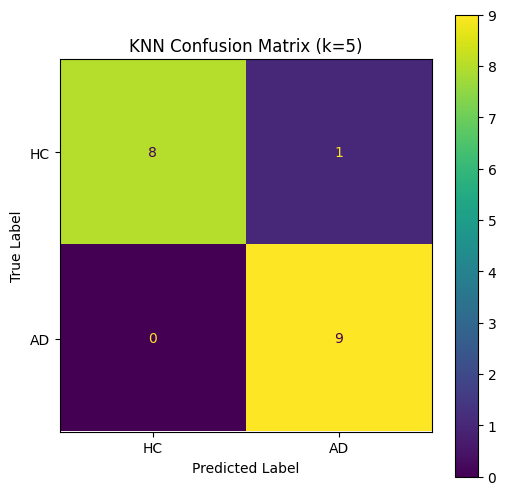

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, y_pred_knn)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HC", "AD"])
disp.plot(ax=ax)

plt.title("KNN Confusion Matrix (k=5)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [40]:
results = {
    "Logistic Regression": accuracy_score(y, y_pred_logreg),
    "SVM": accuracy_score(y, y_pred_svm),
    "Random Forest": accuracy_score(y, y_pred_rf),
    "Gradient Boosting": accuracy_score(y, y_pred_gb),
    "KNN": accuracy_score(y, y_pred_knn)
}

print("Model Accuracy Comparison")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.3f}")

Model Accuracy Comparison
Logistic Regression: 0.889
SVM: 0.778
Random Forest: 0.778
Gradient Boosting: 0.611
KNN: 0.944


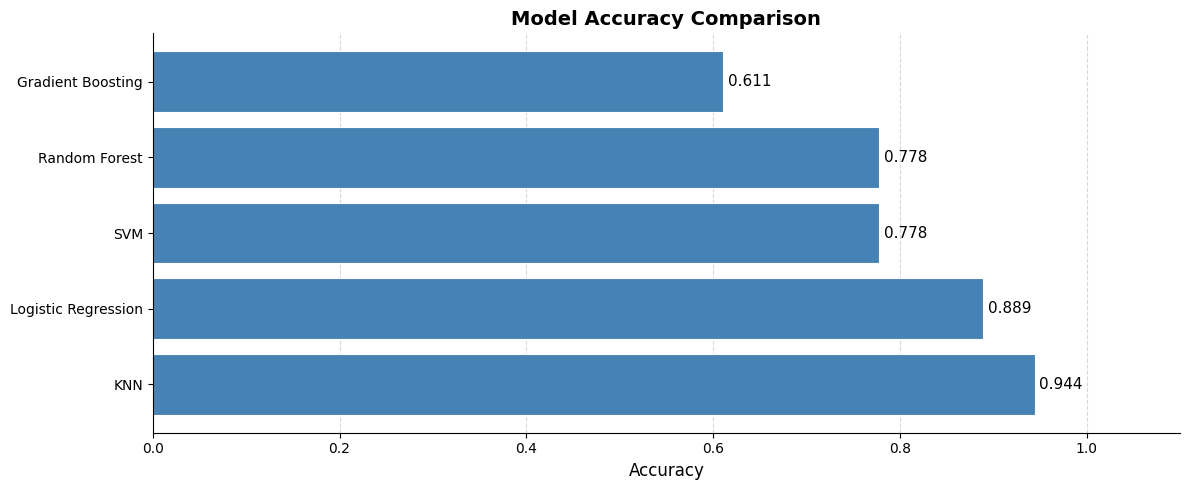

In [41]:
import matplotlib.pyplot as plt

results = {
    "KNN": accuracy_score(y, y_pred_knn),
    "Logistic Regression": accuracy_score(y, y_pred_logreg),
    "SVM": accuracy_score(y, y_pred_svm),
    "Random Forest": accuracy_score(y, y_pred_rf),
    "Gradient Boosting": accuracy_score(y, y_pred_gb),
}

models = list(results.keys())
accuracies = list(results.values())

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(models, accuracies, color="steelblue", edgecolor="white", linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{acc:.3f}", va="center", fontsize=11)

ax.set_xlim(0, 1.1)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

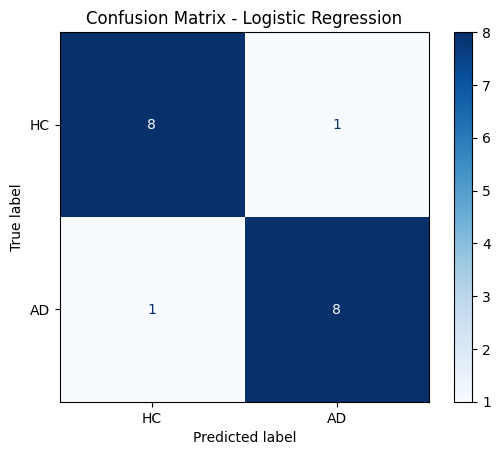

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_logreg,
    display_labels=["HC", "AD"],
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

K-Nearest Neighbors (KNN) achieved the highest accuracy (0.944), correctly classifying 17/18 subjects. The confusion matrix shows that all Alzheimer’s subjects were correctly identified, with only one Healthy Control misclassified. This strong performance suggests that the EEG bandpower features form clear clusters in the feature space, allowing KNN to effectively distinguish between AD and HC based on similarity.

Logistic Regression also performed well (0.889), correctly classifying 16 out of 18 subjects. Its strong performance indicates that the relationship between EEG bandpower features and class labels is largely linear. In contrast, SVM and Random Forest achieved moderate accuracy (0.778), with more misclassifications, particularly in identifying Alzheimer’s subjects. Gradient Boosting performed the worst (0.611), likely due to overfitting and instability caused by the small dataset size.

Although KNN achieved the highest accuracy, this result should be interpreted with caution due to the small dataset size (18 subjects) and the use of Leave-One-Out Cross Validation. KNN is a memory-based model that performs well on small, well-separated datasets but may not generalize as effectively to new data, suggesting that the extracted EEG features are highly informative, and that simpler models are sufficient to capture the key differences between Alzheimer’s Disease and Healthy Controls.